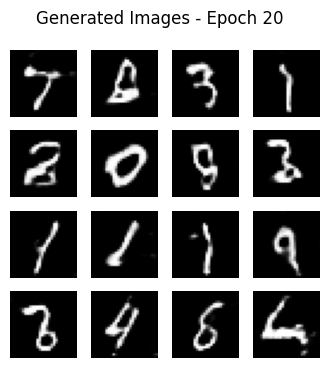

Epoch 20/20
Generator Loss: 0.8319
Discriminator Loss: 1.2925


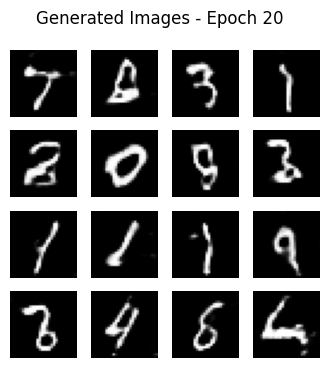

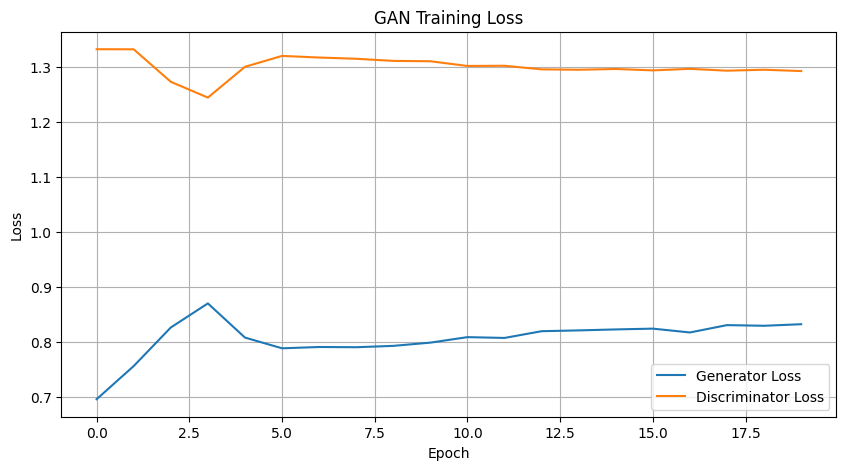

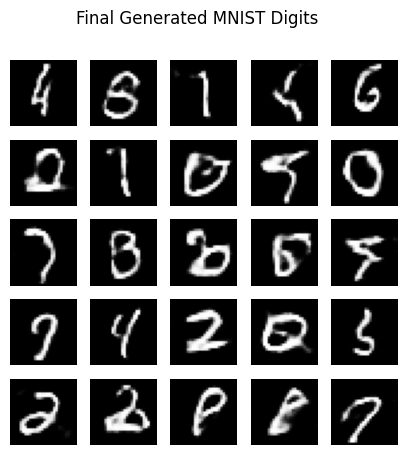

In [1]:
# ============================================
# AI and GenAI Assignment
# Generative Adversarial Network (GAN)
# Using TensorFlow 2.x (Keras API)
# Dataset: MNIST
# ============================================

# ============================================
# STEP 1: IMPORT LIBRARIES
# ============================================

import tensorflow as tf
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
import os
from IPython.display import clear_output

print("TensorFlow Version:", tf.__version__)


# ============================================
# STEP 2: LOAD AND PREPROCESS DATASET
# ============================================

# Load MNIST dataset
(x_train, _), (_, _) = tf.keras.datasets.mnist.load_data()

# Normalize images to range [-1, 1]
x_train = (x_train.astype('float32') - 127.5) / 127.5

# Reshape to (28, 28, 1)
x_train = np.expand_dims(x_train, axis=-1)

print("Training Data Shape:", x_train.shape)

# Batch and shuffle dataset
BUFFER_SIZE = 60000
BATCH_SIZE = 128

dataset = tf.data.Dataset.from_tensor_slices(x_train)
dataset = dataset.shuffle(BUFFER_SIZE).batch(BATCH_SIZE)


# ============================================
# STEP 3: DEFINE HYPERPARAMETERS
# ============================================

NOISE_DIM = 100
EPOCHS = 20

# Adam optimizer parameters
LEARNING_RATE = 0.0002
BETA_1 = 0.5


# ============================================
# STEP 4: BUILD GENERATOR MODEL
# Architecture:
# Dense → BatchNormalization → LeakyReLU
# → Conv2DTranspose → Output (Tanh)
# ============================================

def build_generator():

    model = tf.keras.Sequential(name="Generator")

    # Input Layer
    model.add(layers.Dense(7 * 7 * 256, use_bias=False, input_shape=(NOISE_DIM,)))

    model.add(layers.BatchNormalization())

    model.add(layers.LeakyReLU())

    # Reshape
    model.add(layers.Reshape((7, 7, 256)))

    # Conv2DTranspose Layer 1
    model.add(layers.Conv2DTranspose(
        128,
        kernel_size=(5, 5),
        strides=(1, 1),
        padding='same',
        use_bias=False
    ))

    model.add(layers.BatchNormalization())

    model.add(layers.LeakyReLU())

    # Conv2DTranspose Layer 2
    model.add(layers.Conv2DTranspose(
        64,
        kernel_size=(5, 5),
        strides=(2, 2),
        padding='same',
        use_bias=False
    ))

    model.add(layers.BatchNormalization())

    model.add(layers.LeakyReLU())

    # Output Layer
    model.add(layers.Conv2DTranspose(
        1,
        kernel_size=(5, 5),
        strides=(2, 2),
        padding='same',
        use_bias=False,
        activation='tanh'
    ))

    return model


generator = build_generator()

generator.summary()


# ============================================
# STEP 5: BUILD DISCRIMINATOR MODEL
# Architecture:
# Conv2D → LeakyReLU → Dropout
# → Flatten → Dense (Sigmoid)
# ============================================

def build_discriminator():

    model = tf.keras.Sequential(name="Discriminator")

    # Conv Layer 1
    model.add(layers.Conv2D(
        64,
        kernel_size=(5, 5),
        strides=(2, 2),
        padding='same',
        input_shape=[28, 28, 1]
    ))

    model.add(layers.LeakyReLU())

    model.add(layers.Dropout(0.3))

    # Conv Layer 2
    model.add(layers.Conv2D(
        128,
        kernel_size=(5, 5),
        strides=(2, 2),
        padding='same'
    ))

    model.add(layers.LeakyReLU())

    model.add(layers.Dropout(0.3))

    # Flatten
    model.add(layers.Flatten())

    # Output Layer
    model.add(layers.Dense(1, activation='sigmoid'))

    return model


discriminator = build_discriminator()

discriminator.summary()


# ============================================
# STEP 6: DEFINE LOSS FUNCTION
# Binary Cross Entropy (BCE)
# ============================================

cross_entropy = tf.keras.losses.BinaryCrossentropy()


# Discriminator Loss
def discriminator_loss(real_output, fake_output):

    real_loss = cross_entropy(
        tf.ones_like(real_output),
        real_output
    )

    fake_loss = cross_entropy(
        tf.zeros_like(fake_output),
        fake_output
    )

    total_loss = real_loss + fake_loss

    return total_loss


# Generator Loss
def generator_loss(fake_output):

    return cross_entropy(
        tf.ones_like(fake_output),
        fake_output
    )


# ============================================
# STEP 7: DEFINE OPTIMIZERS
# Adam Optimizer
# learning rate = 0.0002
# beta_1 = 0.5
# ============================================

generator_optimizer = tf.keras.optimizers.Adam(
    learning_rate=LEARNING_RATE,
    beta_1=BETA_1
)

discriminator_optimizer = tf.keras.optimizers.Adam(
    learning_rate=LEARNING_RATE,
    beta_1=BETA_1
)


# ============================================
# STEP 8: CHECKPOINTS (OPTIONAL)
# ============================================

checkpoint_dir = './training_checkpoints'

checkpoint_prefix = os.path.join(checkpoint_dir, "ckpt")

checkpoint = tf.train.Checkpoint(
    generator_optimizer=generator_optimizer,
    discriminator_optimizer=discriminator_optimizer,
    generator=generator,
    discriminator=discriminator
)


# ============================================
# STEP 9: GENERATE AND SAVE IMAGES
# Display grid of generated images
# ============================================

seed = tf.random.normal([16, NOISE_DIM])


def generate_and_save_images(model, epoch, test_input):

    predictions = model(test_input, training=False)

    fig = plt.figure(figsize=(4, 4))

    for i in range(predictions.shape[0]):

        plt.subplot(4, 4, i + 1)

        # Convert back from [-1,1] to [0,255]
        img = predictions[i, :, :, 0] * 127.5 + 127.5

        plt.imshow(img, cmap='gray')

        plt.axis('off')

    plt.suptitle(f"Generated Images - Epoch {epoch}")

    plt.show()


# ============================================
# STEP 10: TRAINING STEP
# ============================================

generator_losses = []
discriminator_losses = []


@tf.function
def train_step(images):

    noise = tf.random.normal([BATCH_SIZE, NOISE_DIM])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:

        # Generate fake images
        generated_images = generator(noise, training=True)

        # Discriminator predictions
        real_output = discriminator(images, training=True)

        fake_output = discriminator(generated_images, training=True)

        # Calculate losses
        gen_loss = generator_loss(fake_output)

        disc_loss = discriminator_loss(real_output, fake_output)

    # Gradients
    gradients_of_generator = gen_tape.gradient(
        gen_loss,
        generator.trainable_variables
    )

    gradients_of_discriminator = disc_tape.gradient(
        disc_loss,
        discriminator.trainable_variables
    )

    # Apply gradients
    generator_optimizer.apply_gradients(
        zip(gradients_of_generator, generator.trainable_variables)
    )

    discriminator_optimizer.apply_gradients(
        zip(gradients_of_discriminator, discriminator.trainable_variables)
    )

    return gen_loss, disc_loss


# ============================================
# STEP 11: TRAIN THE GAN
# Train for at least 20 epochs
# ============================================

def train(dataset, epochs):

    for epoch in range(epochs):

        gen_loss_avg = 0
        disc_loss_avg = 0
        batch_count = 0

        for image_batch in dataset:

            gen_loss, disc_loss = train_step(image_batch)

            gen_loss_avg += gen_loss
            disc_loss_avg += disc_loss

            batch_count += 1

        # Average losses
        gen_loss_avg /= batch_count
        disc_loss_avg /= batch_count

        # Store losses
        generator_losses.append(gen_loss_avg.numpy())
        discriminator_losses.append(disc_loss_avg.numpy())

        # Clear output
        clear_output(wait=True)

        # Generate images every epoch
        generate_and_save_images(generator, epoch + 1, seed)

        # Print losses
        print(f"Epoch {epoch + 1}/{epochs}")
        print(f"Generator Loss: {gen_loss_avg:.4f}")
        print(f"Discriminator Loss: {disc_loss_avg:.4f}")

        # Save model every 5 epochs
        if (epoch + 1) % 5 == 0:
            checkpoint.save(file_prefix=checkpoint_prefix)

    # Final image generation
    generate_and_save_images(generator, epochs, seed)


# ============================================
# STEP 12: START TRAINING
# ============================================

train(dataset, EPOCHS)


# ============================================
# STEP 13: PLOT LOSS CURVES
# Plot Generator and Discriminator Loss
# ============================================

plt.figure(figsize=(10, 5))

plt.plot(generator_losses, label='Generator Loss')

plt.plot(discriminator_losses, label='Discriminator Loss')

plt.xlabel('Epoch')

plt.ylabel('Loss')

plt.title('GAN Training Loss')

plt.legend()

plt.grid(True)

plt.show()


# ============================================
# STEP 14: GENERATE FINAL IMAGES
# ============================================

noise = tf.random.normal([25, NOISE_DIM])

generated_images = generator(noise, training=False)

plt.figure(figsize=(5, 5))

for i in range(25):

    plt.subplot(5, 5, i + 1)

    img = generated_images[i, :, :, 0] * 127.5 + 127.5

    plt.imshow(img, cmap='gray')

    plt.axis('off')

plt.suptitle("Final Generated MNIST Digits")

plt.show()


# ============================================
# END OF PROGRAM
# ============================================